# Kinematic quantification and plotting

Plot x position, y position, speed and angular head velocity for selected recordings.

Run settings → load → calculate → select → plot. Measurements are calculated on each full recording before trial selection. Each recording gets its own figures and retains its acquired time in seconds.


In [14]:
# ===============================================================================
# 1 | Locate This Checkout and Refresh Project Imports After Source Changes
# ===============================================================================

from pathlib import Path
from runpy import run_path

# --- 1.1 | Locate src/ from the checkout root or any notebook subdirectory -------
source_root = next((
    candidate
    for parent in (Path.cwd(), *Path.cwd().parents)
    for candidate in (parent, parent / "src")
    if (candidate / "data_conduit").is_dir() and (candidate / "movement_figures").is_dir()
), None)
if source_root is None:
    raise FileNotFoundError("Open this notebook inside the data-conduit checkout.")

# --- 1.2 | Refresh cached project modules before importing the refactored API ----
# Load the bootstrap by file path: even a cached older package cannot shadow it.
# Rerun the following cells afterwards to rebuild data and figures consistently.
refresh_project_imports = run_path(
    str(source_root / "movement_figures" / "notebook_setup.py")
)["refresh_project_imports"]
source_root = refresh_project_imports(source_root)

# --- 1.3 | Import the analysis and plotting functions from this checkout ---------

import matplotlib.pyplot as plt
from matplotlib.axes import Axes
from matplotlib.figure import Figure
from matplotlib.ticker import MaxNLocator
import movement
import movement.kinematics as kin
import numpy as np
import pandas as pd
import xarray as xr
from IPython.display import display
from movement.utils.vector import compute_signed_angle_2d

from data_conduit.datastructures import slice_stream, slice_stream_for_trial
from data_conduit.integrations.DLC.pose import pose_to_movement
from data_conduit.refactor_qc.training_filter import filter_trials
from movement_figures.data_template.loading import build_datastructure, prepare_pose
from movement_figures.timeseries_template.annotations import (
    QC_OUTCOME_STYLES,
    annotate_qc_timeseries,
    qc_annotations,
)

print(f"movement {movement.__version__}: {movement.__file__}")


movement 0.17.0: /home/sepi/anaconda3/envs/data-conduit-refactor/lib/python3.12/site-packages/movement/__init__.py


## Recording selection, processing and display settings

In [15]:
# === 1| Choose recordings from the existing mouse/day directory hierarchy ========

ROOT = Path("/media/sepi/Elements/PathIntegrationProtocol/BonsaiOutput/Training")
LEVEL_NAMES = ("mouseID", "day")
LEVEL_SELECTORS = {"l0_selector": "MR_M01569515", "l1_selector": "Day21"}
INCLUDE_SESSIONS = ("2026-06-21T093349Z",)                         # Original recording; None includes every folder matching the selectors.
SOURCES = ("trials", "events", "dlc")                            # Kinematic traces require no decoded video background.

# Set LEVEL_SELECTORS={} and INCLUDE_SESSIONS=None to select all mice/days/recordings.
# The manifest printed below shows the stable session IDs used as dictionary keys.

# === 2| Choose actual DLC labels and the camera convention ========================

INDIVIDUAL = "individual_0"                                      # Label assigned by the single-animal DLC conversion.
TRACKING_KEYPOINT = "body"                                       # This landmark supplies x, y and linear speed.
LEFT_EAR, RIGHT_EAR = "lear", "rear"                              # Anatomical left and right ears define the forward vector.
CAMERA_VIEW = "top_down"                                         # +x points right and +y points down in this recording.

# === 3| Apply optional processing before calculating any derivative ===============

CONFIDENCE_THRESHOLD = 0.9                                      # Mask likelihood below 0.9; inspect missing counts before trusting plots.
MAX_GAP_FRAMES = None                                           # None leaves gaps; a positive count fills only short internal gaps.
SMOOTHING_WINDOW = None                                         # None leaves coordinates unsmoothed; otherwise use an odd count >= 3.
SPATIAL_UNIT = "px"                                             # "cm" divides position by each recording's measured pixels/cm.
PIXELS_PER_CM_BY_SESSION = {}                                   # Supply real positive scales keyed by IDs from the manifest.

# === 4| Select trial rows before the plotting functions receive any data ===========

TRIAL_IDS = (1, 2, 3)                                           # Select these original 1-based IDs independently in every recording.
TIME_WINDOW = None                                             # Optional (start, end) seconds intersects, rather than overrides, trials.
TRAINING_SPEC = None                                            # Optional real table from refactor_qc.training_filter.training_spec().
EXCLUDE_LED_ON_SESSIONS = False                                 # True drops an entire recording containing any trial marked LED ON.
ROW_DURATION_S = 25.0                                           # Every displayed row covers this many seconds; no selection occurs here.

# TRAINING_SPEC applies the existing session allowlist, initial-trial cuts and cue-
# trial exclusions. LED ON means an ON event was found within a parsed trial; it
# does not reconstruct continuous hardware state. The whole-session toggle checks
# the unfiltered table so training cuts cannot conceal a session's ON trials.

## Load ordinary streams and inspect which trials are eligible

In [16]:
# === 1| Configure and load the existing DataStructure =============================

session_data = build_datastructure(
    ROOT,
    level_names=LEVEL_NAMES,                                    # Directory labels become trial columns and pose coordinates.
    include=INCLUDE_SESSIONS,                                   # None keeps every session matching the level selectors.
    streams=SOURCES,                                            # Pose loading uses video timestamps internally, without decoding images.
    **LEVEL_SELECTORS,
)
recording_refs = session_data.select()                          # Preview the folders before the readers run.
display(pd.DataFrame([
    {"session": session_id, "path": str(ref.path), **ref.levels}
    for session_id, ref in recording_refs.items()
]))
streams = session_data.load()                                  # Returns the existing plain stream mapping; load performs a fresh selection.

# === 2| Keep recording identity while exposing folder names for training rules ====

all_trials = streams["trials"].copy()                           # Subsequent selections must not modify the loaded source table.
all_trials["session_name"] = all_trials["session"].map({
    session_id: ref.path.name for session_id, ref in session_data.sessions.items()
})                                                             # Training rules name folders; session remains the unambiguous stream ID.
excluded_sessions = []
if EXCLUDE_LED_ON_SESSIONS:
    excluded_sessions = all_trials.loc[
        all_trials["LED"] == "ON", "session"
    ].unique().tolist()                                         # Inspect all original trials before any trial-level exclusion.

# === 3| Reuse the existing refactor_qc training rules when explicitly supplied =====

eligible_trials = all_trials
if TRAINING_SPEC is not None:
    training_rules = TRAINING_SPEC.rename(columns={"session": "session_name"})
    eligible_trials = filter_trials(
        eligible_trials,
        training_rules,
        session_column="session_name",                         # Join the actual folder names without replacing stable session IDs.
        report=False,                                          # Display the resulting rows below instead of a second text report.
    )
if excluded_sessions:
    eligible_trials = slice_stream(
        eligible_trials,
        where=lambda rows: ~rows["session"].isin(excluded_sessions),
    )
if TRIAL_IDS is not None:
    eligible_trials = slice_stream(eligible_trials, selectors={"trial_index": list(TRIAL_IDS)})

display(eligible_trials)                                        # Confirm retained recording/trial IDs before pose conversion and calculation.
print("Excluded LED-ON recordings:", excluded_sessions)

,session,path,mouseID,day
0,2026-06-21T093349Z,/media/sepi/Elements/PathIntegrationProtocol/B...,MR_M01569515,Day21



                  If any files/paths are missing or invalid for the monosource_data_arrays you specified, 
                  you may not see warnings about them. Set verbose=True to enable warnings.
                  

                  If any files/paths are missing or invalid for the monosource_data_arrays you specified, 
                  you may not see warnings about them. Set verbose=True to enable warnings.
                  


,trial_index,start_time,end_time,start_inclusive,end_inclusive,first_event_index,last_event_index,tz_triggered_time,tz_available_time,ChosenPort,...,outbound_start_inclusive,outbound_end_inclusive,inbound_start_time,inbound_end_time,inbound_start_inclusive,inbound_end_inclusive,session,mouseID,day,session_name
0,1,5633.836992,5667.029120,True,True,1,12,5663.198976,5640.910976,0,...,True,True,5663.198976,5667.029120,True,True,2026-06-21T093349Z,MR_M01569515,Day21,2026-06-21T093349Z
1,2,5667.029120,5681.075968,False,True,13,27,5678.849984,5675.540992,0,...,False,True,5678.849984,5681.075968,True,True,2026-06-21T093349Z,MR_M01569515,Day21,2026-06-21T093349Z
2,3,5681.075968,5695.245088,False,True,28,42,5693.349984,5690.241984,0,...,False,True,5693.349984,5695.245088,True,True,2026-06-21T093349Z,MR_M01569515,Day21,2026-06-21T093349Z


Excluded LED-ON recordings: []


## Calculate measurements for each recording

`kin.compute_speed` uses acquired time. Angular head velocity is the signed angle between successive ear-derived head vectors divided by the elapsed time.

This handles the ±π angle wrap, assuming less than π rotation between frames. The first sample and intervals with missing ears remain NaN. Positive rotation is clockwise in image coordinates with y pointing down.


In [17]:
# === 1| Validate the requested measurement units before processing recordings ======

if SPATIAL_UNIT not in ("px", "cm"):
    raise ValueError("SPATIAL_UNIT must be 'px' or 'cm'.")
recordings = {}                                                # Ordinary per-recording results; raw clocks are never concatenated here.
pose_sessions = []                                              # No DLC output means every recording is skipped with an explanation below.
if "dlc:position" in streams and "dlc:confidence" in streams:
    pose_sessions = pd.unique(streams["dlc:position"].session.values).tolist()

# === 2| Select one recording before conversion, filtering and differentiation ======

for session_id in session_data.sessions:
    trial_rows = slice_stream(eligible_trials, selectors={"session": session_id})
    if trial_rows.empty or session_id not in pose_sessions:
        print(f"Skipping {session_id}: no eligible trials or no aligned pose.")
        continue

    aligned_position = slice_stream(streams["dlc:position"], selectors={"session": session_id})
    aligned_confidence = slice_stream(streams["dlc:confidence"], selectors={"session": session_id})
    raw_pose = pose_to_movement(
        aligned_position, aligned_confidence, individual=INDIVIDUAL,
    )                                                         # Reuse the DLC converter; its time coordinate remains acquisition seconds.
    pose = prepare_pose(
        raw_pose,
        confidence_threshold=CONFIDENCE_THRESHOLD,             # Mask low-likelihood coordinates before calculating any derivative.
        max_gap_frames=MAX_GAP_FRAMES,                         # None leaves missing positions as gaps.
        smoothing_window=SMOOTHING_WINDOW,                     # None preserves the surviving measured coordinates.
    )
    position = pose.position.sel(individual=INDIVIDUAL, drop=True)

    # === 2.1| Validate the landmarks used by the two movement calls ================

    if position.sizes["time"] < 2:
        raise ValueError(f"{session_id}: at least two pose frames are required.")
    for keypoint in (TRACKING_KEYPOINT, LEFT_EAR, RIGHT_EAR):
        if keypoint not in position.keypoint.values:
            raise ValueError(f"{session_id}: unknown keypoint {keypoint!r}.")

    # === 2.2| Apply this recording's measured scale to every landmark ==============

    if SPATIAL_UNIT == "cm":
        pixels_per_cm = PIXELS_PER_CM_BY_SESSION.get(session_id)
        if pixels_per_cm is None or not np.isfinite(pixels_per_cm) or pixels_per_cm <= 0:
            raise ValueError(f"{session_id}: supply a finite positive pixels/cm calibration.")
        position = position / pixels_per_cm                    # Pixel displacement divided by pixels/cm becomes centimetres.
    position.attrs = {**position.attrs, "units": SPATIAL_UNIT}
    point = position.sel(keypoint=TRACKING_KEYPOINT, drop=True)

    # === 2.3| Ask movement for speed and the ear-defined forward vector ============

    linear_speed = kin.compute_speed(point)                    # Differentiate on this recording's actual seconds, before slicing trials.
    linear_speed = linear_speed.where(point.notnull().all("space"))
    head_direction = kin.compute_head_direction_vector(
        position,
        left_keypoint=LEFT_EAR,                                # Anatomical left defines the orientation of the ear axis.
        right_keypoint=RIGHT_EAR,                              # Anatomical right supplies the other end of that axis.
        camera_view=CAMERA_VIEW,                               # Choose the correct forward perpendicular for this camera view.
    )

    # === 2.4| Convert signed head rotation into radians per preceding second =======

    previous_head = head_direction.shift(time=1)                # Shift vector values while retaining the current sample's clock.
    head_rotation = compute_signed_angle_2d(previous_head, head_direction)
    elapsed_seconds = head_direction.time - head_direction.time.shift(time=1)
    angular_velocity = head_rotation / elapsed_seconds          # First frame and missing vector pairs remain NaN.

    # === 2.5| Name the four measurements and record their physical units ===========

    measurements = xr.Dataset({
        "x_position": point.sel(space="x", drop=True),
        "y_position": point.sel(space="y", drop=True),
        "linear_speed": linear_speed,
        "angular_head_velocity": angular_velocity,
    })
    for name, units in (
        ("x_position", SPATIAL_UNIT),
        ("y_position", SPATIAL_UNIT),
        ("linear_speed", f"{SPATIAL_UNIT}/s"),
        ("angular_head_velocity", "rad/s"),
    ):
        measurements[name].attrs["units"] = units

    # === 2.6| Keep this recording's results and inspect missing coordinates =========

    recordings[session_id] = {
        "raw_pose": raw_pose, "pose": pose, "measurements": measurements,
        "trials": trial_rows,
        "events": slice_stream(streams["events"], selectors={"session": session_id}),
    }
    print(f"{session_id}: {int(point.notnull().all('space').sum())}/{point.sizes['time']} valid tracked-point frames")

2026-06-21T093349Z: 35654/36354 valid tracked-point frames


## Select trial intervals before plotting

`TRIAL_IDS` selects original trial numbers within each recording. `TIME_WINDOW` optionally restricts them further. Samples outside the selected trials become NaN, preventing lines across excluded intervals. Event IDs preserve the order of equal-time annotations.

With `TRIAL_IDS=None` and both training and LED exclusions disabled, selection retains the full recording.


In [18]:
# === 1| Validate an optional time intersection on each recording's own clock ======

if TIME_WINDOW is not None:
    window_start, window_end = map(float, TIME_WINDOW)
    if not np.isfinite([window_start, window_end]).all() or window_start >= window_end:
        raise ValueError("TIME_WINDOW needs two finite increasing times in seconds.")
restrict_to_trials = TRIAL_IDS is not None or TRAINING_SPEC is not None or EXCLUDE_LED_ON_SESSIONS
selected_recordings = {}                                      # Each entry contains only that recording's selected data and annotations.

# === 2| Form the union of the chosen trial rows for one recording at a time =========

for session_id, recording in recordings.items():
    measurements = recording["measurements"]
    trials = recording["trials"]
    events = recording["events"]
    keep_pose = xr.ones_like(measurements.time, dtype=bool)
    keep_events = np.ones(len(events), dtype=bool)

    if restrict_to_trials:
        keep_pose = xr.zeros_like(measurements.time, dtype=bool)
        keep_events = np.zeros(len(events), dtype=bool)
        for _, trial_row in trials.iterrows():
            trial_measurements = slice_stream_for_trial(measurements, trial_row, time_coord="time")
            trial_events = slice_stream_for_trial(events, trial_row, time_coord="Time")
            keep_pose = keep_pose | measurements.time.isin(trial_measurements.time)
            keep_events = keep_events | events["event_index"].isin(trial_events["event_index"]).to_numpy()

    # === 2.1| Intersect both streams with the requested absolute time interval ======

    if TIME_WINDOW is not None:
        keep_pose = keep_pose & (measurements.time >= window_start) & (measurements.time <= window_end)
        keep_events = keep_events & (events.index >= window_start) & (events.index <= window_end)
        trials = slice_stream(
            trials,
            where=lambda rows: (rows["start_time"] <= window_end) & (rows["end_time"] >= window_start),
        )                                                     # Keep only annotation rows overlapping the requested interval.
    selected_clock = slice_stream(measurements.time, where=keep_pose)
    if selected_clock.sizes["time"] < 2:
        print(f"Skipping {session_id}: selection contains fewer than two pose frames.")
        continue

    # === 2.2| Keep omitted intervals as NaNs and trim only unused recording ends =====

    selected_measurements = measurements.where(keep_pose)       # NaNs retain a visible break between nonadjacent selected trials.
    selected_measurements = slice_stream(
        selected_measurements,
        start=float(selected_clock.time.values[0]),
        end=float(selected_clock.time.values[-1]),
        time_coord="time",
    )
    selected_recordings[session_id] = {
        "measurements": selected_measurements,
        "trials": trials,
        "events": slice_stream(events, where=keep_events),
    }

In [19]:
# === 1| Define the reusable single-recording trace plot =======================

def plot_wrapped_kinematic_trace(
    trace: xr.DataArray,
    trials: pd.DataFrame,
    events: pd.DataFrame | None,
    *,
    row_duration_s: float,
    ylabel: str,
    title: str,
    y_mode: str = "data",
    y_limits: tuple[float, float] | None = None,
    max_gap_s: float | None = None,
    color: str = "#5b4b9a",
) -> tuple[Figure, np.ndarray]:
    """Draw one measurement in consecutive rows of equal duration.

    Measurements are calculated before this function is called. Each row
    retains the acquired session clock, and all rows share the same y scale.
    NaNs and large acquisition gaps break the line. The final row's unused
    tail is shaded, keeping one second equally wide in every row.

    Parameters
    ----------
    trace : xarray.DataArray
        One measurement with dimensions (time,) and at least two finite,
        strictly increasing time coordinates in session seconds. The caller
        must select recordings, trial samples and time first. Values use
        the units named in ylabel; NaN values remain visible gaps.
    trials : pandas.DataFrame
        Already selected rows from the trace's recording, with start_time and
        end_time in session seconds. Q_C outcome and phase columns are used
        when present. Trial rows do not change which trace samples are drawn.
    events : pandas.DataFrame or None
        Already selected event rows from the same recording and clock, used by
        annotate_qc_timeseries. None omits raw event markers.
    row_duration_s : float
        Finite positive width of every row in seconds, including the final row.
    ylabel : str
        Axis label with measurement units, for example "Linear speed (px/s)".
    title : str
        Overall figure title, normally naming the recording and landmark.
    y_mode : {"data", "nonnegative", "symmetric"}, default "data"
        "data" pads the observed range; "nonnegative" starts at zero;
        "symmetric" centres the range on zero. All rows share the same limits.
    y_limits : tuple[float, float] or None, default None
        Explicit increasing (lower, upper) limits in measurement units.
        These override y_mode; None derives limits from visible finite values.
    max_gap_s : float or None, default None
        Break lines when neighbouring acquisition times differ by more than
        this positive duration in seconds. None uses five times the median
        recorded frame interval. This affects drawing only, never measurements.
    color : str, default "#5b4b9a"
        Matplotlib colour specification for the measurement trace.

    Returns
    -------
    figure : matplotlib.figure.Figure
        Newly created figure with a shared annotation legend when available.
        The function does not show or save it; the caller controls both.
    axes : numpy.ndarray
        One-dimensional array of matplotlib.axes.Axes in chronological row
        order, including a one-element array when only one row is needed.
    """
    # === 1| Reject ambiguous clocks and invalid display settings ==================
    # One-dimensional input prevents multiple animals or recordings being silently
    # superimposed. Strictly increasing times make row slicing deterministic.

    if trace.dims != ("time",):
        raise ValueError("trace must be one-dimensional with a time coordinate.")
    times = np.asarray(trace.time.values, dtype=float)
    if len(times) < 2 or not np.isfinite(times).all() or not (np.diff(times) > 0).all():
        raise ValueError("trace needs at least two finite, strictly increasing times.")
    start, end = float(times[0]), float(times[-1])               # The supplied trace already defines the selected clock span.
    if not np.isfinite(row_duration_s) or row_duration_s <= 0:
        raise ValueError("row_duration_s must be finite and positive.")
    if y_mode not in {"data", "nonnegative", "symmetric"}:
        raise ValueError("y_mode must be 'data', 'nonnegative' or 'symmetric'.")
    gap_limit = 5 * float(np.median(np.diff(times))) if max_gap_s is None else float(max_gap_s)
    if not np.isfinite(gap_limit) or gap_limit <= 0:
        raise ValueError("max_gap_s must be finite and positive when supplied.")

    # === 2| Choose one y range from every supplied finite measurement =============
    # A shared range allows peaks in different rows to be compared directly.
    # An all-missing trace receives a finite default range and a visible message.

    finite_values = trace.values[np.isfinite(trace.values)]
    if y_limits is None:
        low = float(finite_values.min()) if finite_values.size else 0.0
        high = float(finite_values.max()) if finite_values.size else 1.0
        if y_mode == "symmetric":
            limit = max(abs(low), abs(high)) or 1.0
            y_limits = (-1.05 * limit, 1.05 * limit)
        elif y_mode == "nonnegative":
            y_limits = (0.0, 1.05 * max(high, 1.0))
        else:
            padding = 0.05 * (high - low) if high > low else max(1.0, abs(low) * 0.05)
            y_limits = (low - padding, high + padding)
    if not np.isfinite(y_limits).all() or y_limits[0] >= y_limits[1]:
        raise ValueError("y_limits must contain two increasing finite values.")

    # === 3| Create successive time rows with a shared measurement scale ===========

    row_count = max(1, int(np.ceil((end - start) / row_duration_s)))
    # Floating-point rounding can add an empty row at an exact duration multiple.
    while row_count > 1 and start + (row_count - 1) * row_duration_s >= end:
        row_count -= 1
    figure, axes_grid = plt.subplots(
        row_count,
        1,
        squeeze=False,
        sharey=True,
        figsize=(14, 2.65 * row_count + 1.1),
        layout="constrained",
    )
    axes = axes_grid[:, 0]
    legend_handles = {}
    # Keep outcome symbols near the top in axes coordinates; the annotation
    # helper accepts heights from 0 to 1. The shared legend remains outside.
    outcome_styles = {
        outcome: {**style, "height": 0.98, "markersize": 6}
        for outcome, style in QC_OUTCOME_STYLES.items()
    }
    for row_number, ax in enumerate(axes):
        row_start = start + row_number * row_duration_s
        row_stop = start + (row_number + 1) * row_duration_s
        selected_stop = min(row_stop, end)
        row_trace = trace.sel(time=slice(row_start, selected_stop))  # Select a drawing panel, without changing the supplied trial union.
        row_times = np.asarray(row_trace.time.values, dtype=float)
        row_values = np.asarray(row_trace.values, dtype=float)

        # === 3.1| Break the line across missing observations and acquisition gaps ==
        # Insert a NaN between separated samples, retaining both measured endpoints.
        gap_positions = np.flatnonzero(np.diff(row_times) > gap_limit) + 1
        if gap_positions.size:
            gap_times = (row_times[gap_positions - 1] + row_times[gap_positions]) / 2
            row_times = np.insert(row_times, gap_positions, gap_times)
            row_values = np.insert(row_values, gap_positions, np.nan)
        ax.plot(row_times, row_values, color=color, linewidth=1.15, zorder=3)
        if not np.isfinite(row_values).any():
            ax.text(
                0.5, 0.5, "No valid measurements in this row",
                transform=ax.transAxes, ha="center", color="0.4", fontsize=10,
            )
        ax.set_ylim(*y_limits)

        # === 3.2| Draw only the supplied annotations on their original clock =======
        # The window clips annotation drawing to this panel; it cannot select
        # another experimental trial or add an event absent from the input table.

        annotations = annotate_qc_timeseries(
            ax,
            trials,
            events,
            window=(row_start, selected_stop),
            outcome_styles=outcome_styles,
            legend=False,
        )
        for handle in annotations.legend_handles:
            legend_handles.setdefault(handle.get_label(), handle)

        # === 3.3| Keep one second equally wide on every displayed row ==============
        # The final row retains a complete row width without including later trials.

        if selected_stop < row_stop:
            ax.axvspan(selected_stop, row_stop, color="0.94", zorder=0)
        ax.set_xlim(row_start, row_stop)
        ax.set_ylabel(ylabel, fontsize=11)
        ax.set_xlabel("Session time (s)", fontsize=10)
        ax.set_title(f"Row {row_number + 1}", loc="left", fontsize=10, pad=13)
        ax.xaxis.set_major_locator(MaxNLocator(nbins=7))
        ax.ticklabel_format(axis="x", style="plain", useOffset=False)
        ax.tick_params(labelsize=10)
        ax.grid(axis="y", color="0.9", linewidth=0.6)
        ax.spines[["top", "right"]].set_visible(False)

    # === 4| Place the shared legend outside the traces and return plot handles =====

    figure.suptitle(title, fontsize=15, fontweight="semibold")
    if legend_handles:
        figure.legend(
            list(legend_handles.values()),
            list(legend_handles),
            loc="outside lower center",
            ncol=4,
            fontsize=9,
            frameon=False,
        )
    return figure, axes

# === 2| Define plotting across the already selected recordings ====================

def plot_recording_kinematic_traces(
    selected_recordings: dict[str, dict[str, xr.Dataset | pd.DataFrame]],
    *,
    measurement_name: str,
    measurement_label: str,
    tracking_keypoint: str,
    row_duration_s: float,
    y_mode: str = "data",
) -> dict[str, tuple[Figure, np.ndarray]]:
    """Return one wrapped measurement figure for each selected recording.

    Parameters
    ----------
    selected_recordings : dict[str, dict]
        Mapping from stable recording ID to its selected "measurements"
        xarray.Dataset, "trials" DataFrame, and "events" DataFrame. Every
        measurement uses a one-dimensional time coordinate in session seconds
        and has a "units" attribute, such as "px", "cm/s" or "rad/s". Retain
        NaNs between excluded trials so the plotted line cannot join them.
    measurement_name : str
        Dataset variable to draw, for example "x_position" or "linear_speed".
    measurement_label : str
        Human-readable measurement name, without units. The trace's "units"
        attribute supplies units in the y-axis label for each recording.
    tracking_keypoint : str
        Landmark label included in each figure title, such as "body".
        This is a display label; landmark selection happens before plotting.
    row_duration_s : float
        Finite positive width of every plotted row in session seconds.
    y_mode : {"data", "nonnegative", "symmetric"}, default "data"
        Y-axis scaling passed to plot_wrapped_kinematic_trace: observed range,
        a zero lower bound, or a range centred on zero, respectively.

    Returns
    -------
    dict[str, tuple[matplotlib.figure.Figure, numpy.ndarray]]
        Recording IDs mapped to their new figure and one-dimensional array
        of row axes. An empty selection returns an empty dictionary. Figures
        are neither shown nor saved, and input measurements are unchanged.
    """
    # === 1| Retain each recording's clock and annotations in its own figure =======
    figures = {}
    for session_id, selected in selected_recordings.items():
        trace = selected["measurements"][measurement_name]

        # === 1.1| Read measured units and delegate the complete drawing layout ====
        figure, axes = plot_wrapped_kinematic_trace(
            trace,                            # Values and trial selection are already final.
            selected["trials"],                # Annotations belong to this recording only.
            selected["events"],                # Selection has already preserved tied event IDs.
            row_duration_s=row_duration_s,
            ylabel=f"{measurement_label} ({trace.attrs['units']})",
            title=f"{session_id} · {tracking_keypoint} · {measurement_label}",
            y_mode=y_mode,
        )
        figures[session_id] = (figure, axes)   # Keep handles available for display or export.

    # === 2| Return every figure without changing caller-controlled display ========
    return figures


## Plot each selected measurement

`plot_recording_kinematic_traces` creates one figure per recording and returns
figure/axes pairs keyed by recording ID. It delegates row layout, annotation and
axis styling to `plot_wrapped_kinematic_trace`. The cells below only configure
and call these functions, then display the returned figures.

`ROW_DURATION_S` changes row length without changing trial selection or measured
values. Positions and speed use `SPATIAL_UNIT`; centimetres require each
recording's measured calibration. Angular velocity uses radians per second.
These are time-series plots; their x-axis is session time rather than video space.


In [20]:
# === 1| Confirm each recording's trial IDs and selected clock before drawing ========

for session_id, selected in selected_recordings.items():
    print(session_id, "trials:", selected["trials"]["trial_index"].tolist())
    display(selected["measurements"])

2026-06-21T093349Z trials: [1, 2, 3]


<xarray.Dataset> Size: 157kB
Dimensions:                (time: 1228)
Coordinates:
  * time                   (time) float64 10kB 5.634e+03 5.634e+03 ... 5.695e+03
    session                (time) <U18 88kB '2026-06-21T093349Z' ... '2026-06...
    mouseID                (time) object 10kB 'MR_M01569515' ... 'MR_M01569515'
    day                    (time) object 10kB 'Day21' 'Day21' ... 'Day21'
Data variables:
    x_position             (time) float64 10kB 1.377e+03 1.382e+03 ... 918.0
    y_position             (time) float64 10kB 460.1 471.3 475.5 ... 107.1 107.5
    linear_speed           (time) float64 10kB 315.3 192.7 184.4 ... 11.04 16.43
    angular_head_velocity  (time) float64 10kB -4.683 -0.7575 ... -0.3328 1.31

## x position


In [21]:
# # === 1| Draw x position for every selected recording =======================

# x_position_figures = plot_recording_kinematic_traces(
#     selected_recordings,                     # Selected trials and measured values are reused.
#     measurement_name="x_position",
#     measurement_label="x position",              # Units are read from each measurement's metadata.
#     tracking_keypoint=TRACKING_KEYPOINT,
#     row_duration_s=ROW_DURATION_S,            # Wrapping changes presentation only.
#     y_mode="data",
# )
# plt.show()                                   # Display remains under the notebook caller's control.


## y position


In [22]:
# # === 1| Draw y position for every selected recording =======================

# y_position_figures = plot_recording_kinematic_traces(
#     selected_recordings,                     # Selected trials and measured values are reused.
#     measurement_name="y_position",
#     measurement_label="y position",              # Units are read from each measurement's metadata.
#     tracking_keypoint=TRACKING_KEYPOINT,
#     row_duration_s=ROW_DURATION_S,            # Wrapping changes presentation only.
#     y_mode="data",
# )
# plt.show()                                   # Display remains under the notebook caller's control.


## Linear speed


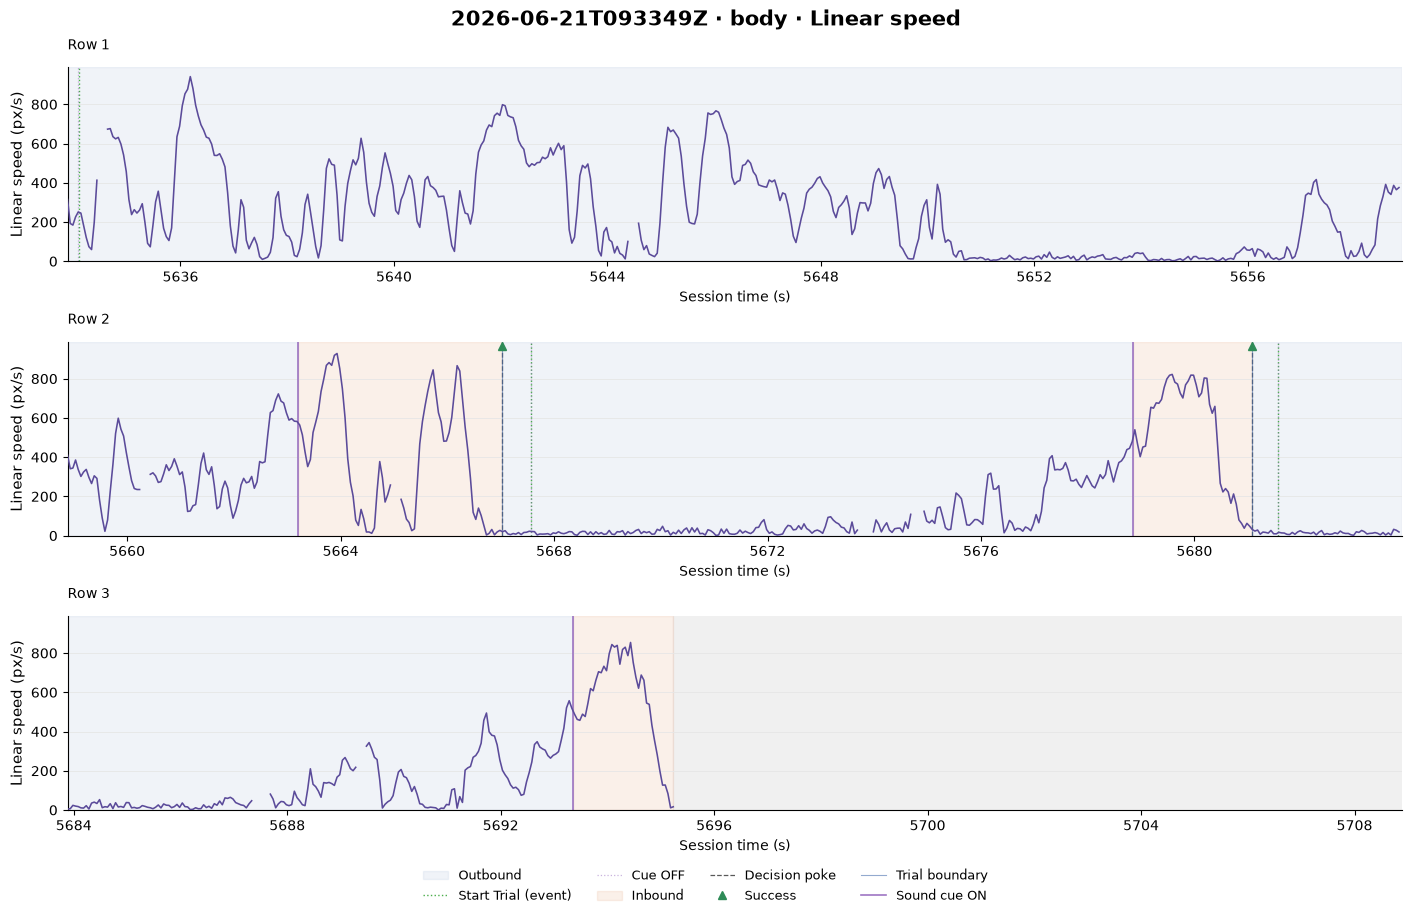

In [23]:
# === 1| Draw linear speed for every selected recording =======================

linear_speed_figures = plot_recording_kinematic_traces(
    selected_recordings,                     # Selected trials and measured values are reused.
    measurement_name="linear_speed",
    measurement_label="Linear speed",              # Units are read from each measurement's metadata.
    tracking_keypoint=TRACKING_KEYPOINT,
    row_duration_s=ROW_DURATION_S,            # Wrapping changes presentation only.
    y_mode="nonnegative",
)
plt.show()                                   # Display remains under the notebook caller's control.


## Angular head velocity


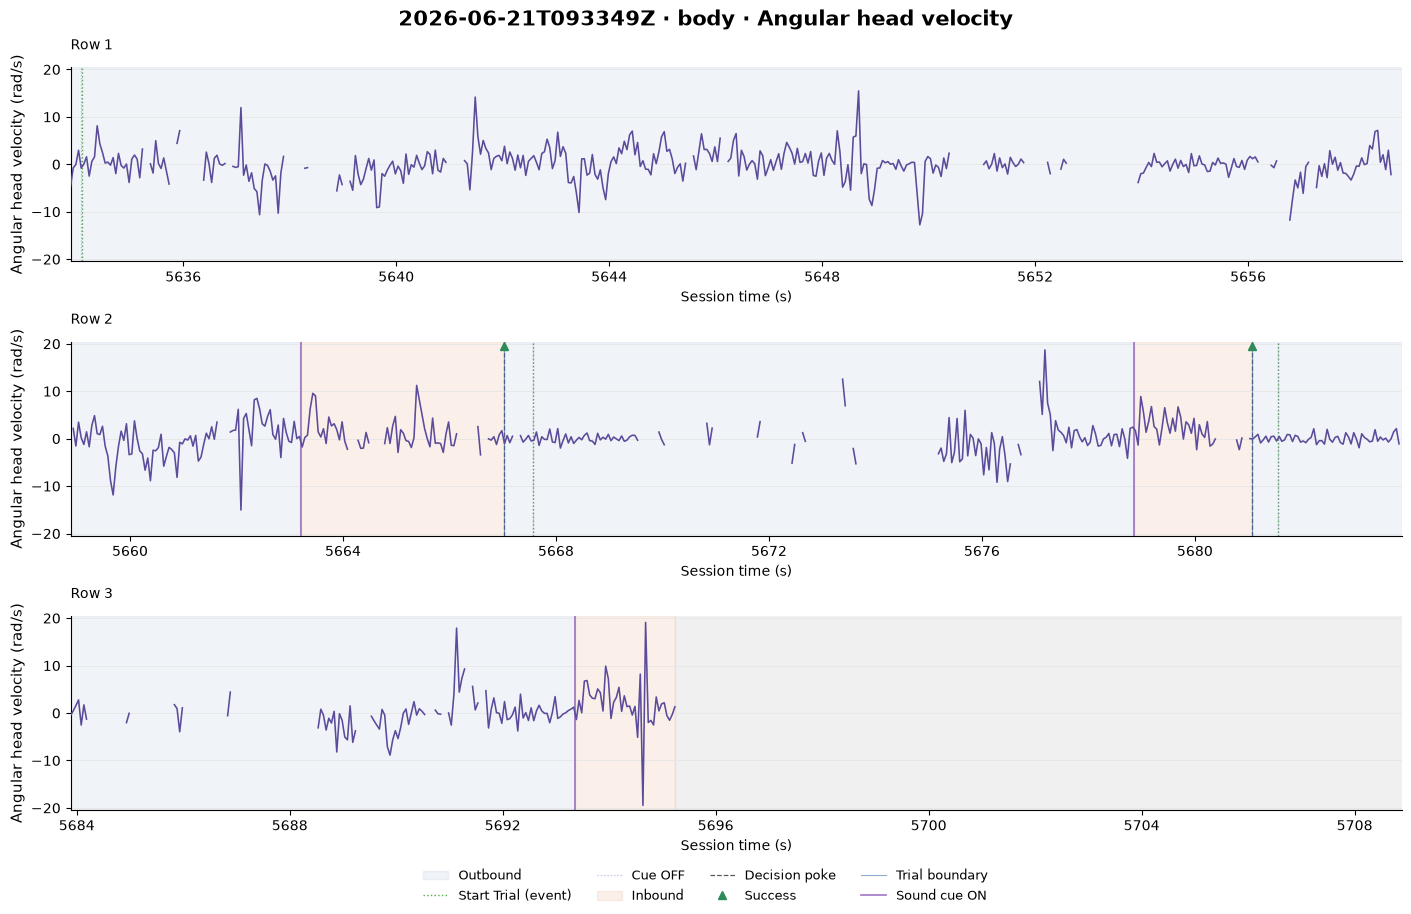

In [24]:
# === 1| Draw angular head velocity for every selected recording =======================

angular_head_velocity_figures = plot_recording_kinematic_traces(
    selected_recordings,                     # Selected trials and measured values are reused.
    measurement_name="angular_head_velocity",
    measurement_label="Angular head velocity",              # Units are read from each measurement's metadata.
    tracking_keypoint=TRACKING_KEYPOINT,
    row_duration_s=ROW_DURATION_S,            # Wrapping changes presentation only.
    y_mode="symmetric",
)
plt.show()                                   # Display remains under the notebook caller's control.


Movement reference: [speed](https://movement.neuroinformatics.dev/latest/api/movement.kinematics.compute_speed.html), [head direction](https://movement.neuroinformatics.dev/latest/api/movement.kinematics.compute_head_direction_vector.html), [signed angle](https://movement.neuroinformatics.dev/latest/api/movement.utils.vector.compute_signed_angle_2d.html).
